In [1]:
from matplotlib import pyplot as plt
import numpy as np
import math

In [1]:
lambda_seed = 1030e-9 #central wavelength of the Seed pulse
eta_index = 1 #refractive index of the medium
r_input = 24/2#1/e^2 radius of the input beam (Seed output size from the compressor)


theta_in = 0# input divergence of the Seed [rad]; very well collimated!
w_in_x = 8.5e-3 #input beam size along X DIMENSION (1/e^2 intensity radius) [m]
w_in_y = 9.3e-3 #input beam size along Y DIMENSION (1/e^2 intensity radius) [m]
R_in_x = math.inf #input beam curvature along Y DIMENSION
R_in_y = math.inf #input beam curvature along Y DIMENSION

q_in_x = 1/(1/R_in_x-1j*lambda_seed/(np.pi*eta_index*w_in_x**2)) #complex q parameter of the gaussian beam at the input; X dimension
q_in_y = 1/(1/R_in_y-1j*lambda_seed/(np.pi*eta_index*w_in_y**2)) #complex q parameter of the gaussian beam at the input; Y dimension

d_to_scraper = 7935e-3 #distance of the last telescope mirror to the input scraper mirror
d_scraper_to_grid = 7950e-3 #distance from the input scraper to the first grid mirror
d_grid_to_grid = 8000e-3#8173e-3 #distance from grid to grid

R_scraper_in = 8000e-3 #Radius of curvature of the input scraper mirror
R_right = 4000e-3 #radius of curvature of the mirrors on the right grid
R_left = 4000e-3 #radius of curvature of the mirrors on the left grid
R_scraper_out = 12000e-3 #radius of curvature of the output scraper mirror (placed in the right chamber)

f_scraper_in = R_scraper_in/2 #focal length of the input scraper mirror
f_right = R_right/2 #focal length of the right grid mirrors
f_left = R_left/2 #focal length of the right grid mirrors
f_scraper_out = R_scraper_out/2 #focal length of the output scraper mirror (placed in the right chamber)

def ABCD_free(d):
    """ABCD matrix for free-space propagation over distance d."""
    return np.array([[1,d],[0,1]])

def ABCD_mirror(R):
    """ABCD matrix for reflection from a spherical mirror with radius R."""
    f = R / 2
    return np.array([[1, 0], [-1/f, 1]])

def apply_ABCD(M, q):
    """Apply ABCD matrix M to complex q parameter."""
    A = M[0, 0]
    B = M[0, 1]
    C = M[1, 0]
    D = M[1, 1]
    return (A * q + B) / (C * q + D)


def w_from_q(q, wavelength, eta=1.0):
    """Compute beam radius from complex q."""
    Im_1_q = np.imag(1 / q)
    if Im_1_q == 0:
        return np.inf  # perfectly collimated
    return np.sqrt(wavelength / (np.pi * eta * abs(Im_1_q)))

w_x = []#list of beam sizes to be populated (X-dimension)
w_y = []#list of beam sizes to be populated (Y-dimension)
w_foc_x = [] #list of focus sizes to be populated (X-dimension)
w_foc_y = [] #list of focus sizes to be populated (Y-dimension)


q_scraper_in_x = apply_ABCD(M=ABCD_free(d=d_to_scraper),q=q_in_x) #complex beam parameter as incident on the input scraper mirror (X-dimension)
q_scraper_in_y = apply_ABCD(M=ABCD_free(d=d_to_scraper),q=q_in_y) #complex beam parameter as incident on the input scraper mirror (Y-dimension)

w_scraper_in_x = w_from_q(q=q_scraper_in_x,wavelength=lambda_seed,eta=eta_index) #find the beam radius on the input scraper mirror (X-dimension)
w_scraper_in_y = w_from_q(q=q_scraper_in_y,wavelength=lambda_seed,eta=eta_index) #find the beam radius on the input scraper mirror (Y-dimension)

w_x.append(w_scraper_in_x) #append the beam sizes array with the beam size at the input scraper
w_y.append(w_scraper_in_y) #append the beam sizes array with the beam size at the input scraper

q_after_scraper_in_x = apply_ABCD(M=ABCD_mirror(R=R_scraper_in),q=q_scraper_in_x)
q_after_scraper_in_y = apply_ABCD(M=ABCD_mirror(R=R_scraper_in),q=q_scraper_in_y)

q_focus_0_x = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid/2),q=q_after_scraper_in_x) #complex beam parameter in the focus created by the input scraper mirror
q_focus_0_y = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid/2),q=q_after_scraper_in_y) #complex beam parameter in the focus created by the input scraper mirror

w_focus_0_x = w_from_q(q=q_focus_0_x, wavelength=lambda_seed, eta=eta_index)
w_focus_0_y = w_from_q(q=q_focus_0_y, wavelength=lambda_seed, eta=eta_index)

w_foc_x.append(w_focus_0_x) #append the focus size (after the input scraper) into the list of focus sizes (X-dimension)
w_foc_y.append(w_focus_0_y) #append the focus size (after the input scraper) into the list of focus sizes (Y-dimension)

q_at_M1_x = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid),q=q_after_scraper_in_x) #complex beam parameter at the first grid mirror (right side); X-dimension
q_at_M1_y = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid),q=q_after_scraper_in_y) #complex beam parameter at the first grid mirror (right side); Y-dimension

w_M1_x = w_from_q(q=q_at_M1_x, wavelength=lambda_seed, eta=eta_index) #beam size on the first grid mirror (right grid); X-dimension
w_M1_y = w_from_q(q=q_at_M1_y, wavelength=lambda_seed, eta=eta_index) #beam size on the first grid mirror (right grid); Y-dimension

w_x.append(w_M1_x) #append the beam sizes list with the beam size at M1 (X)
w_x.append(w_M1_y) #append the beam sizes list with the beam size at M1 (Y)

q_after_M1_x = apply_ABCD(M=ABCD_mirror(R=R_right),q=q_at_M1_x)
q_after_M1_y = apply_ABCD(M=ABCD_mirror(R=R_right),q=q_at_M1_y)




# Total number of mirror hits
num_mirrors = 36

# Start from q_after_M1_x (after the first right grid mirror)
q_current_x = q_after_M1_x
q_current_y = q_after_M1_y

# Loop through remaining mirrors
for i in range(2, num_mirrors + 1):
    # Determine current mirror side
    if i % 2 == 0:
        # Even-numbered mirror: left side
        R_current = R_left
    else:
        # Odd-numbered mirror: right side
        R_current = R_right

    # Propagate to next mirror (grid-to-grid distance)
    q_before_mirror_x = apply_ABCD(ABCD_free(d_grid_to_grid), q_current_x)
    q_before_mirror_y = apply_ABCD(ABCD_free(d_grid_to_grid), q_current_y)

    # Record beam size at mirror
    w_at_mirror_x = w_from_q(q_before_mirror_x, lambda_seed, eta_index)
    w_at_mirror_y = w_from_q(q_before_mirror_y, lambda_seed, eta_index)
    w_x = np.append(w_x, w_at_mirror_x)
    w_y = np.append(w_y, w_at_mirror_y)

    # Apply mirror curvature
    q_after_mirror_x = apply_ABCD(ABCD_mirror(R_current), q_before_mirror_x)
    q_after_mirror_y = apply_ABCD(ABCD_mirror(R_current), q_before_mirror_y)

    # Propagate to focus (midpoint between mirrors)
    q_focus_x = apply_ABCD(ABCD_free(d_grid_to_grid / 2), q_after_mirror_x)
    q_focus_y = apply_ABCD(ABCD_free(d_grid_to_grid / 2), q_after_mirror_y)

    # Record focus size
    w_focus_x = w_from_q(q_focus_x, lambda_seed, eta_index)
    w_focus_y = w_from_q(q_focus_y, lambda_seed, eta_index)
    w_foc_x = np.append(w_foc_x, w_focus_x)
    w_foc_y = np.append(w_foc_y, w_focus_y)

    # Update q for next step
    q_current_x = q_after_mirror_x
    q_current_y = q_after_mirror_y


w_x = np.array(w_x) #cast lists to arrays
w_y = np.array(w_y) #cast lists to arrays
w_foc_x = np.array(w_foc_x)
w_foc_y = np.array(w_foc_y)

plt.plot(w_x*1e3,'--o')
plt.plot(w_y*1e3,'--o')

NameError: name 'math' is not defined

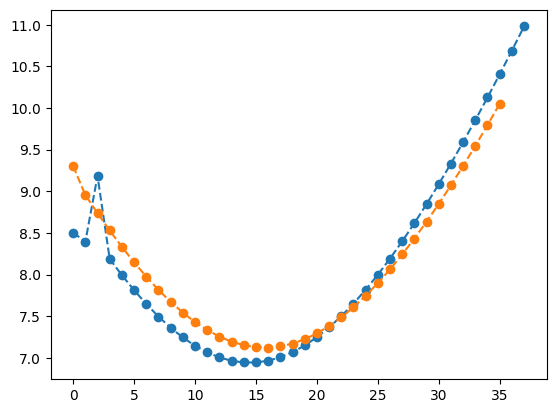

In [4]:

#plt.ylim(0,10)

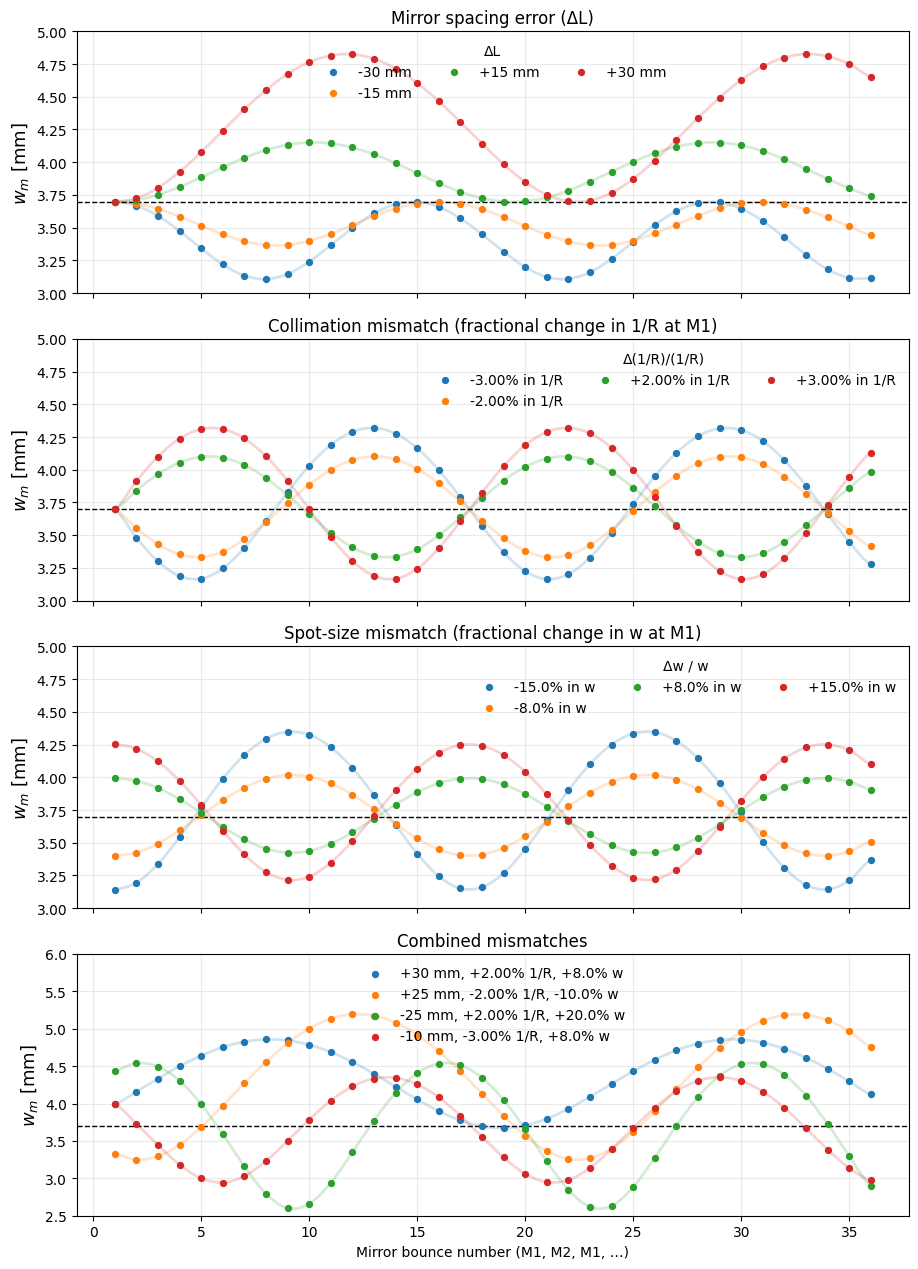

In [44]:
import numpy as np
import math
import matplotlib.pyplot as plt

# -----------------------
# Cavity & wavelength
# -----------------------
lambda0 = 1030e-9   # wavelength [m]
R1 = R2 = 4.0       # concave mirrors [m]
L0 = 7.927          # nominal separation [m]
n_bounces = 36      # total mirror bounces to show (M1, M2, M1, ...)
ymin=3
ymax=5

# -----------------------
# Sweeps
# -----------------------
deltaLs_mm   = [-30.0, -15.0, 15.0, 30.0]         # Row 1: spacing error [mm]
curv_frac_ls = [-0.03, -0.02, 0.02, 0.03] # Row 2: frac change in 1/R at injection
eps_w_ls     = [-0.15, -0.08, 0.08, 0.15]       # Row 3: frac change in w at injection
combined_cases = [
    (+30.0, +0.02, +0.08),  # reinforce (watch upper bound)
    (+25.0, -0.02, -0.10),  # cancel stronger
    (-25.0, +0.02, +0.20),  # cancel stronger
    #(+10.0, +0.03, -0.08),  # mixed signs
    (-10.0, -0.03, +0.08),  # mixed signs
]

alpha=0.2


# -----------------------
# ABCD utilities
# -----------------------
def ABCD_free(d):       return np.array([[1.0, d], [0.0, 1.0]])
def ABCD_mirror(R):     return np.array([[1.0, 0.0], [-2.0/R, 1.0]])  # mirror power 2/R

def apply_ABCD(M, q):
    A,B = M[0,0], M[0,1]
    C,D = M[1,0], M[1,1]
    return (A*q + B) / (C*q + D)

def round_trip_matrix(R1, R2, L):
    P = ABCD_free(L); M1 = ABCD_mirror(R1); M2 = ABCD_mirror(R2)
    # Start just AFTER reflection at M1
    return M1 @ P @ M2 @ P

def eigen_q_at_M1(R1, R2, L):
    """q at M1 just AFTER reflection (pick Im(q)>0 root)."""
    M = round_trip_matrix(R1, R2, L)
    A,B,C,D = M[0,0], M[0,1], M[1,0], M[1,1]
    a, b, c = C, (D - A), -B
    disc = complex(b*b - 4*a*c)
    q1 = (-b + np.sqrt(disc)) / (2*a)
    q2 = (-b - np.sqrt(disc)) / (2*a)
    return q1 if np.imag(q1) > 0 else q2

def w_from_q(q, wavelength, n=1.0):
    Im_1_q = np.imag(1.0/q)
    return np.inf if Im_1_q == 0 else math.sqrt(wavelength / (math.pi * n * abs(Im_1_q)))

def R_from_q(q):
    Re_1_q = np.real(1.0/q)
    return np.inf if abs(Re_1_q) < 1e-20 else 1.0 / Re_1_q

def q_from_w_R(w, R, wavelength, n=1.0):
    return 1.0 / (((0.0 if np.isinf(R) else 1.0/R)) - 1j * wavelength/(math.pi*n*w**2))

def stable(L, R1, R2):
    gprod = (1 - L/R1) * (1 - L/R2)
    return (0 < gprod < 1), gprod

# -----------------------
# Eigenmode (reference)
# -----------------------
q_M1_eig = eigen_q_at_M1(R1, R2, L0)         # M1, just after reflection
w_m_eig  = w_from_q(q_M1_eig, lambda0)
R_wave_eig = R_from_q(q_M1_eig)

# -----------------------
# Correct per-hit simulator (M1 & M2 arrays)
# -----------------------
def simulate_hits(R1, R2, L, q_start, wavelength, n_hits=20):
    """
    q_start at M1 just AFTER reflection.
    Returns w_M1[k], w_M2[k] for k=1..n_hits.
    """
    w_M1, w_M2 = [], []
    q = q_start
    for _ in range(n_hits):
        w_M1.append(w_from_q(q, wavelength))          # at M1
        q = apply_ABCD(ABCD_free(L), q)               # to M2
        w_M2.append(w_from_q(q, wavelength))          # at M2
        q = apply_ABCD(ABCD_mirror(R2), q)            # reflect at M2
        q = apply_ABCD(ABCD_free(L), q)               # back to M1
        q = apply_ABCD(ABCD_mirror(R1), q)            # reflect at M1
    return np.array(w_M1), np.array(w_M2)

def interleave_bounces(w_M1, w_M2, n_bounces):
    """
    Build [M1_1, M2_1, M1_2, M2_2, ...] and clip to n_bounces.
    """
    m = len(w_M1)
    out = np.empty(2*m)
    out[0::2] = w_M1
    out[1::2] = w_M2
    return out[:n_bounces]

# -----------------------
# Smooth spline (Catmull–Rom, uniform parameterization)
# -----------------------
def catmull_rom_spline(y, samples_per_seg=20):
    """
    y: 1D array of values at integer x = 1..N
    Returns (x_smooth, y_smooth) with smooth curve through all points.
    """
    y = np.asarray(y, dtype=float)
    N = y.size
    xs, ys = [], []
    for i in range(N-1):
        p0 = y[i-1] if i-1 >= 0 else y[i]         # clamp ends
        p1 = y[i]
        p2 = y[i+1]
        p3 = y[i+2] if (i+2) < N else y[i+1]
        ts = np.linspace(0.0, 1.0, samples_per_seg, endpoint=False)
        # Catmull–Rom basis
        for t in ts:
            t2 = t*t; t3 = t2*t
            val = 0.5*((2*p1)
                       + (-p0 + p2)*t
                       + (2*p0 - 5*p1 + 4*p2 - p3)*t2
                       + (-p0 + 3*p1 - 3*p2 + p3)*t3)
            ys.append(val)
            xs.append((i+1) + t)                  # segment i spans [i+1, i+2]
    # add last point
    xs.append(N); ys.append(y[-1])
    return np.array(xs), np.array(ys)

# -----------------------
# Plot: 4 rows × 1 column, 36 bounces each (smooth lines + dots)
# -----------------------
fig, axes = plt.subplots(4, 1, figsize=(9.2, 12.8), sharex=True)
x_bounce = np.arange(1, n_bounces + 1)

# ---------- Row 1: ΔL mismatch ----------
ax = axes[0]
for dLmm in deltaLs_mm:
    Lp = L0 + 1e-3*dLmm
    ok, gprod = stable(Lp, R1, R2)
    if not ok:
        continue
    w1, w2 = simulate_hits(R1, R2, Lp, q_M1_eig, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)          # meters
    xs, ys = catmull_rom_spline(1e3*sizes)                 # mm, smooth
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)               # smooth curve
    ax.scatter(x_bounce, 1e3*sizes, s=18, zorder=3, color=line.get_color(), label=f"{dLmm:+.0f} mm")
    ws1 = w_from_q(eigen_q_at_M1(R1, R2, Lp), lambda0)
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
ax.set_title("Mirror spacing error (ΔL)")
ax.set_ylabel(r"$w_m$ [mm]",size=13)
ax.grid(alpha=0.25)
ax.legend(title="ΔL", frameon=False, ncols=3, loc='best')
ax.set_ylim(ymin, ymax)

# ---------- Row 2: collimation (curvature) mismatch ----------
ax = axes[1]
kappa_eig = 0.0 if np.isinf(R_wave_eig) else 1.0/R_wave_eig
for frac in curv_frac_ls:
    kappa_inj = kappa_eig*(1+frac)
    R_inj = np.inf if abs(kappa_inj) < 1e-20 else 1.0/kappa_inj
    q_inj = q_from_w_R(w_m_eig, R_inj, lambda0)           # same w, perturbed curvature
    w1, w2 = simulate_hits(R1, R2, L0, q_inj, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)
    xs, ys = catmull_rom_spline(1e3*sizes)
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    ax.scatter(x_bounce, 1e3*sizes, s=18, zorder=3, color=line.get_color(), label=f"{frac*100:+.2f}% in 1/R")
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
ax.set_title("Collimation mismatch (fractional change in 1/R at M1)")
ax.set_ylabel(r"$w_m$ [mm]",size=13)
ax.grid(alpha=0.25)
ax.legend(title="Δ(1/R)/(1/R)", frameon=False, ncols=3, loc='best')
ax.set_ylim(ymin, ymax)

# ---------- Row 3: spot-size mismatch ----------
ax = axes[2]
for eps in eps_w_ls:
    w_inj = w_m_eig*(1+eps)
    q_inj = q_from_w_R(w_inj, R_wave_eig, lambda0)        # keep curvature matched
    w1, w2 = simulate_hits(R1, R2, L0, q_inj, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)
    xs, ys = catmull_rom_spline(1e3*sizes)
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    ax.scatter(x_bounce, 1e3*sizes, s=18, zorder=3, color=line.get_color(), label=f"{eps*100:+.1f}% in w")
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
ax.set_title("Spot-size mismatch (fractional change in w at M1)")
ax.set_ylabel(r"$w_m$ [mm]",size=13)
ax.grid(alpha=0.25)
ax.legend(title="Δw / w", frameon=False, ncols=3, loc='best')
ax.set_ylim(ymin, ymax)

# ---------- Row 4: combined mismatches ----------
ax = axes[3]
for dLmm, frac, eps in combined_cases:
    Lp = L0 + 1e-3*dLmm
    ok, gprod = stable(Lp, R1, R2)
    if not ok:
        continue
    w_inj = w_m_eig*(1+eps)
    kappa_inj = kappa_eig*(1+frac)
    R_inj = np.inf if abs(kappa_inj) < 1e-20 else 1.0/kappa_inj
    q_inj = q_from_w_R(w_inj, R_inj, lambda0)
    w1, w2 = simulate_hits(R1, R2, Lp, q_inj, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)
    xs, ys = catmull_rom_spline(1e3*sizes)
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    ax.scatter(x_bounce, 1e3*sizes, s=18, zorder=3, color=line.get_color(),
               label=f"{dLmm:+.0f} mm, {frac*100:+.2f}% 1/R, {eps*100:+.1f}% w")
    ws1 = w_from_q(eigen_q_at_M1(R1, R2, Lp), lambda0)
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
ax.set_title("Combined mismatches")
ax.set_ylabel(r"$w_m$ [mm]",size=13)
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc='best')
ax.set_ylim(2.5, 6)

axes[-1].set_xlabel("Mirror bounce number (M1, M2, M1, …)")
plt.tight_layout()
plt.show()


0.9638330624999998


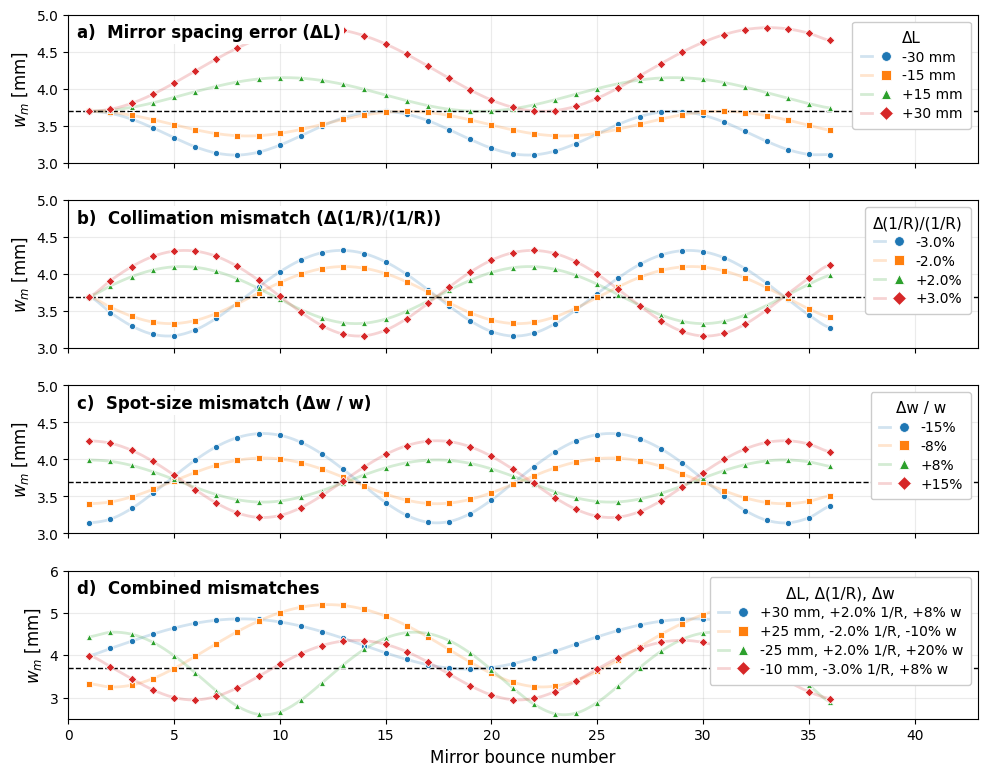

In [76]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# -----------------------
# Cavity & wavelength
# -----------------------
lambda0 = 1030e-9   # wavelength [m]
R1 = R2 = 4.0       # concave mirrors [m]
L0 = 7.927          # nominal separation [m]
n_bounces = 36      # total mirror bounces to show (M1, M2, M1, ...)
ymin = 3
ymax = 5
xmin = 0
xmax = 43

g = 1-L0/R1
print(g**2)

# -----------------------
# Sweeps
# -----------------------
deltaLs_mm   = [-30.0, -15.0, 15.0, 30.0]         # Row 1: spacing error [mm]
curv_frac_ls = [-0.03, -0.02, 0.02, 0.03]         # Row 2: frac change in 1/R at injection
eps_w_ls     = [-0.15, -0.08, 0.08, 0.15]         # Row 3: frac change in w at injection
combined_cases = [
    (+30.0, +0.02, +0.08),   # reinforce
    (+25.0, -0.02, -0.10),   # cancel stronger
    (-25.0, +0.02, +0.20),   # cancel stronger
    (-10.0, -0.03, +0.08),   # mixed signs
]

alpha = 0.2  # line transparency

# Plot marker settings
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*']  # varied shapes
SCATTER_SIZE = 20   # smaller plotted markers (points^2)
LEG_MARKER_SIZE = 7 # legend marker size (points)
LEG_LINE_WIDTH = 2

# -----------------------
# ABCD utilities
# -----------------------
def ABCD_free(d):       return np.array([[1.0, d], [0.0, 1.0]])
def ABCD_mirror(R):     return np.array([[1.0, 0.0], [-2.0/R, 1.0]])  # mirror power 2/R

def apply_ABCD(M, q):
    A,B = M[0,0], M[0,1]
    C,D = M[1,0], M[1,1]
    return (A*q + B) / (C*q + D)

def round_trip_matrix(R1, R2, L):
    P = ABCD_free(L); M1 = ABCD_mirror(R1); M2 = ABCD_mirror(R2)
    # Start just AFTER reflection at M1
    return M1 @ P @ M2 @ P

def eigen_q_at_M1(R1, R2, L):
    """q at M1 just AFTER reflection (pick Im(q)>0 root)."""
    M = round_trip_matrix(R1, R2, L)
    A,B,C,D = M[0,0], M[0,1], M[1,0], M[1,1]
    a, b, c = C, (D - A), -B
    disc = complex(b*b - 4*a*c)
    q1 = (-b + np.sqrt(disc)) / (2*a)
    q2 = (-b - np.sqrt(disc)) / (2*a)
    return q1 if np.imag(q1) > 0 else q2

def w_from_q(q, wavelength, n=1.0):
    Im_1_q = np.imag(1.0/q)
    return np.inf if Im_1_q == 0 else math.sqrt(wavelength / (math.pi * n * abs(Im_1_q)))

def R_from_q(q):
    Re_1_q = np.real(1.0/q)
    return np.inf if abs(Re_1_q) < 1e-20 else 1.0 / Re_1_q

def q_from_w_R(w, R, wavelength, n=1.0):
    return 1.0 / (((0.0 if np.isinf(R) else 1.0/R)) - 1j * wavelength/(math.pi*n*w**2))

def stable(L, R1, R2):
    gprod = (1 - L/R1) * (1 - L/R2)
    return (0 < gprod < 1), gprod

# -----------------------
# Eigenmode (reference)
# -----------------------
q_M1_eig = eigen_q_at_M1(R1, R2, L0)         # M1, just after reflection
w_m_eig  = w_from_q(q_M1_eig, lambda0)
R_wave_eig = R_from_q(q_M1_eig)

# -----------------------
# Per-hit simulator (M1 & M2 arrays), interleave helper
# -----------------------
def simulate_hits(R1, R2, L, q_start, wavelength, n_hits=20):
    """q_start at M1 just AFTER reflection. Returns w_M1[k], w_M2[k] for k=1..n_hits."""
    w_M1, w_M2 = [], []
    q = q_start
    for _ in range(n_hits):
        w_M1.append(w_from_q(q, wavelength))          # at M1
        q = apply_ABCD(ABCD_free(L), q)               # to M2
        w_M2.append(w_from_q(q, wavelength))          # at M2
        q = apply_ABCD(ABCD_mirror(R2), q)            # reflect at M2
        q = apply_ABCD(ABCD_free(L), q)               # back to M1
        q = apply_ABCD(ABCD_mirror(R1), q)            # reflect at M1
    return np.array(w_M1), np.array(w_M2)

def interleave_bounces(w_M1, w_M2, n_bounces):
    """Build [M1_1, M2_1, M1_2, M2_2, ...] and clip to n_bounces."""
    m = len(w_M1)
    out = np.empty(2*m)
    out[0::2] = w_M1
    out[1::2] = w_M2
    return out[:n_bounces]

# -----------------------
# Smooth spline (Catmull–Rom, uniform parameterization)
# -----------------------
def catmull_rom_spline(y, samples_per_seg=20):
    """y: values at integer x = 1..N → (x_smooth, y_smooth)."""
    y = np.asarray(y, dtype=float)
    N = y.size
    xs, ys = [], []
    for i in range(N-1):
        p0 = y[i-1] if i-1 >= 0 else y[i]         # clamp ends
        p1, p2 = y[i], y[i+1]
        p3 = y[i+2] if (i+2) < N else y[i+1]
        ts = np.linspace(0.0, 1.0, samples_per_seg, endpoint=False)
        for t in ts:
            t2 = t*t; t3 = t2*t
            val = 0.5*((2*p1)
                       + (-p0 + p2)*t
                       + (2*p0 - 5*p1 + 4*p2 - p3)*t2
                       + (-p0 + 3*p1 - 3*p2 + p3)*t3)
            ys.append(val)
            xs.append((i+1) + t)                  # segment i spans [i+1, i+2]
    xs.append(N); ys.append(y[-1])
    return np.array(xs), np.array(ys)

# -----------------------
# Aesthetics helpers
# -----------------------
def corner_label(ax, text):
    """Top-left in-axes label replacing subplot title."""
    ax.text(0.01, 0.94, text, transform=ax.transAxes,
            ha='left', va='top', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2))

def legend_handles_stack(line_color, marker, label, line_alpha=1.0):
    """
    Return a (handle, label) where handle is a tuple: (line, marker-only),
    so the legend shows a line with a solid (non-transparent) marker.
    """
    line = Line2D([0], [0], color=line_color, lw=LEG_LINE_WIDTH, alpha=line_alpha, linestyle='-')
    dot  = Line2D([0], [0], color=line_color, marker=marker, linestyle='None',
                  markersize=LEG_MARKER_SIZE, markerfacecolor=line_color,
                  markeredgecolor='white', markeredgewidth=0.6)
    return ( (line, dot), label )

def place_legend(ax, title, handle_label_pairs):
    handles = [h for h, _ in handle_label_pairs]
    labels  = [l for _, l in handle_label_pairs]
    ax.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)},
              title=title, frameon=True, ncol=1, loc='upper right',
              fontsize=10, title_fontsize=11, fancybox=True, framealpha=1.0,
              handlelength=2.2, handletextpad=0.8, borderpad=0.6,
              labelspacing=0.35, columnspacing=0.8)

# -----------------------
# Plot: 4 rows × 1 column
# -----------------------
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
x_bounce = np.arange(1, n_bounces + 1)

# ---------- Row 1: ΔL mismatch ----------
ax = axes[0]
legend_items = []
for idx, dLmm in enumerate(deltaLs_mm):
    Lp = L0 + 1e-3*dLmm
    ok, _ = stable(Lp, R1, R2)
    if not ok:
        continue
    w1, w2 = simulate_hits(R1, R2, Lp, q_M1_eig, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)          # meters
    xs, ys = catmull_rom_spline(1e3*sizes)                 # mm
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    mk = MARKERS[idx % len(MARKERS)]
    ax.scatter(x_bounce, 1e3*sizes, s=SCATTER_SIZE, zorder=3, color=line.get_color(),
               marker=mk, edgecolors='white', linewidths=0.6)
    legend_items.append(legend_handles_stack(line.get_color(), mk, f"{dLmm:+.0f} mm", line_alpha=alpha))
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
corner_label(ax, "a)  Mirror spacing error (ΔL)")
ax.set_ylabel(r"$w_m$ [mm]", fontsize=12)
ax.grid(alpha=0.25)
place_legend(ax, "ΔL", legend_items)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# ---------- Row 2: collimation (curvature) mismatch ----------
ax = axes[1]
legend_items = []
kappa_eig = 0.0 if np.isinf(R_wave_eig) else 1.0/R_wave_eig
for idx, frac in enumerate(curv_frac_ls):
    kappa_inj = kappa_eig*(1+frac)
    R_inj = np.inf if abs(kappa_inj) < 1e-20 else 1.0/kappa_inj
    q_inj = q_from_w_R(w_m_eig, R_inj, lambda0)           # same w, perturbed curvature
    w1, w2 = simulate_hits(R1, R2, L0, q_inj, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)
    xs, ys = catmull_rom_spline(1e3*sizes)
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    mk = MARKERS[idx % len(MARKERS)]
    ax.scatter(x_bounce, 1e3*sizes, s=SCATTER_SIZE, zorder=3, color=line.get_color(),
               marker=mk, edgecolors='white', linewidths=0.6)
    legend_items.append(legend_handles_stack(line.get_color(), mk, f"{frac*100:+.1f}%", line_alpha=alpha))
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
corner_label(ax, "b)  Collimation mismatch (Δ(1/R)/(1/R))")
ax.set_ylabel(r"$w_m$ [mm]", fontsize=12)
ax.grid(alpha=0.25)
place_legend(ax, "Δ(1/R)/(1/R)", legend_items)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# ---------- Row 3: spot-size mismatch ----------
ax = axes[2]
legend_items = []
for idx, eps in enumerate(eps_w_ls):
    w_inj = w_m_eig*(1+eps)
    q_inj = q_from_w_R(w_inj, R_wave_eig, lambda0)        # keep curvature matched
    w1, w2 = simulate_hits(R1, R2, L0, q_inj, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)
    xs, ys = catmull_rom_spline(1e3*sizes)
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    mk = MARKERS[idx % len(MARKERS)]
    ax.scatter(x_bounce, 1e3*sizes, s=SCATTER_SIZE, zorder=3, color=line.get_color(),
               marker=mk, edgecolors='white', linewidths=0.6)
    legend_items.append(legend_handles_stack(line.get_color(), mk, f"{eps*100:+.0f}%", line_alpha=alpha))
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
corner_label(ax, "c)  Spot-size mismatch (Δw / w)")
ax.set_ylabel(r"$w_m$ [mm]", fontsize=12)
ax.grid(alpha=0.25)
place_legend(ax, "Δw / w", legend_items)
ax.set_ylim(ymin, ymax)
ax.set_xlim(xmin, xmax)

# ---------- Row 4: combined mismatches ----------
ax = axes[3]
legend_items = []
for idx, (dLmm, frac, eps) in enumerate(combined_cases):
    Lp = L0 + 1e-3*dLmm
    ok, _ = stable(Lp, R1, R2)
    if not ok:
        continue
    w_inj = w_m_eig*(1+eps)
    kappa_inj = kappa_eig*(1+frac)
    R_inj = np.inf if abs(kappa_inj) < 1e-20 else 1.0/kappa_inj
    q_inj = q_from_w_R(w_inj, R_inj, lambda0)
    w1, w2 = simulate_hits(R1, R2, Lp, q_inj, lambda0, n_hits=(n_bounces+1)//2)
    sizes = interleave_bounces(w1, w2, n_bounces)
    xs, ys = catmull_rom_spline(1e3*sizes)
    line, = ax.plot(xs, ys, lw=2, alpha=alpha)
    mk = MARKERS[idx % len(MARKERS)]
    ax.scatter(x_bounce, 1e3*sizes, s=SCATTER_SIZE, zorder=3, color=line.get_color(),
               marker=mk, edgecolors='white', linewidths=0.6)
    legend_items.append(
        legend_handles_stack(
            line.get_color(), mk,
            f"{dLmm:+.0f} mm, {frac*100:+.1f}% 1/R, {eps*100:+.0f}% w",
            line_alpha=alpha
        )
    )
ax.axhline(1e3*w_m_eig, color='k', ls='dashed', lw=1)
corner_label(ax, "d)  Combined mismatches")
ax.set_ylabel(r"$w_m$ [mm]", fontsize=12)
ax.grid(alpha=0.25)
place_legend(ax, "ΔL, Δ(1/R), Δw", legend_items)
ax.set_ylim(2.5, 6)  # your custom range for the combined row
ax.set_xlim(xmin, xmax)

axes[-1].set_xlabel("Mirror bounce number", fontsize=12)

# Tighter but comfortable spacing
plt.subplots_adjust(left=0.08, right=0.99, top=0.98, bottom=0.10, hspace=0.25)
plt.savefig('/Users/sebastiankalos/Documents/OXFORD/Thesis_writeup/images/plots/mode_matching_sims.png',bbox_inches='tight',dpi=300)
